In [1]:
import serial
import numpy as np
import time
import matplotlib.pyplot as plt
from IPython.display import clear_output, display

plt.style.use('dark_background')


In [25]:
with serial.Serial("COM31", 115200, rtscts=False) as ser:
    ser.write(b'hello\n')
    l = ser.readline().decode()
    print(l)


NEW Name Here Ready



In [29]:
info_outputs = ""
other_outputs = ""
with serial.Serial("COM31", 115200) as ser:
    start_timer = time.time()
    ser.write("R,".encode())
    time.sleep(0.04)
    ser.write(bytearray([72, 1, 0, 4] * 6))
    time.sleep(0.04)
    ser.write(bytearray([42, 1, 1, 3, 0, 4]))

    ser.write(bytearray([0, 0, 0, 1]))
    ser.write(bytearray([0, 0, 1, 0]))
    ser.write(bytearray([0, 1, 0, 0]))
    ser.write(bytearray([1, 0, 0, 0]))
    

    

    while (time.time() - start_timer < 1):
        if ser.in_waiting > 0:
            start_timer = time.time()
            l = ser.read().decode()
            print(l, end = "")

        else:
            time.sleep(.5)
                


R mode
[ 30383][V][data_transfer.cpp:47] get_arr_len(): [DATA_TRANS] GET Array length 4, 4, 4, 4, 4, 4
[ 30383][V][data_transfer.cpp:61] allocate(): [DATA_TRANS] Allocation 16 bytes
[ 30422][E][data_transfer.cpp:108] get_data_arr(): [DATA_TRANS] Data length1:4, double check:4
0
0
data arr 0:  0,65536,256,1,
Arr 1 not init
Arr 2 not init
Arr 3 not init
Arr 4 not init
Arr 5 not init
[ 30433][V][data_transfer.cpp:14] ~DataPtk(): [DATA_TRANS] memory arr[0] freed.


In [57]:
info_outputs = ""
other_outputs = ""
with serial.Serial("COM31", 115200) as ser:
    start_timer = time.time()
    ser.write("R,".encode())
    time.sleep(0.04)
    ser.write(bytearray([72, 1, 0, 4] * 6))
    time.sleep(0.04)
    ser.write(bytearray([42, 1, 1, 3, 0, 4]))

    ser.write(bytearray([0, 0, 0, 1]))
    ser.write(bytearray([0, 0, 1, 0]))
    ser.write(bytearray([0, 1, 0, 0]))
    ser.write(bytearray([1, 0, 0, 0]))
    

    

    while (time.time() - start_timer < 1):
        if ser.in_waiting > 0:
            start_timer = time.time()
            l = ser.read()
            if l[0] < 127:
                print(l.decode(), end = "")
            else:
                print(l)

        else:
            time.sleep(.5)
                


R mode
b'\xca'
[125977][E][data_transfer.cpp:56] get_arr_len(): [DATA_TRANS] TIMEOUT before getting ID
[125977][V][data_transfer.cpp:66] allocate(): [DATA_TRANS] Allocation 0 bytes
[125980][E][data_transfer.cpp:69] allocate(): [DATA_TRANS] Allocation failed
[125987][E][data_transfer.cpp:80] get_data_arr(): [DATA_TRANS] array expected length is 0
-1
Arr 0 not init
Arr 1 not init
Arr 2 not init
Arr 3 not init
Arr 4 not init
Arr 5 not init
BAD COMMAND


In [2]:
def wait_for_control(ser, n, timeout = .1):
    start_timer = time.time()
    while (time.time() - start_timer < timeout):
        if ser.in_waiting > 0:
            b = ser.read()
            if b[0] < 127:
                print(b.decode(), end = "")
                if b == bytes([n]):
                    return 1
            else:
                if b == bytes([n]):
                    return 1
    return -1

In [13]:
with serial.Serial("COM31", 115200) as ser:
    ser.write(bytes([160] + [1, 2, 0, 0, 0, 0, 0, 0]))

    ser.write(bytes([160] + [2, 110, 40, 20, 0, 0, 0, 0]))
    
    ser.write(bytes([160] + [10, 0, 0, 0, 0, 0, 0, 0]))

    wait_for_control(ser, 244, 1)
                


[  2058][V][run_esp.cpp:23] do_esp_cmd(): [ESP] parse ESP commands
[  2064][V][run_esp.cpp:41] do_esp_cmd(): [ESP] cmd is 1, 2, 0, 0, 0, 0, 0, 0
[  2071][V][run_esp.cpp:52] do_esp_cmd(): [ESP] gains are 1, 0, 0, 0, 0, 0
[  2082][V][run_esp.cpp:23] do_esp_cmd(): [ESP] parse ESP commands
[  2088][V][run_esp.cpp:41] do_esp_cmd(): [ESP] cmd is 2, 110, 40, 20, 0, 0, 0, 0
[  2095][V][run_esp.cpp:60] do_esp_cmd(): [ESP] currents are 110, 40, 20
[  2102][V][run_esp.cpp:23] do_esp_cmd(): [ESP] parse ESP commands
[  2108][V][run_esp.cpp:41] do_esp_cmd(): [ESP] cmd is 10, 0, 0, 0, 0, 0, 0, 0
[  2115][V][u_adpd6100.cpp:618] preset_config_1(): [ADPD] Preset_config 1 set for timeslot:0. Two ambient channels. Total 2 x 3 bytes
[  2127][V][u_adpd6100.cpp:666] preset_config_2(): [ADPD] Preset_config 2 set for timeslot:1. Total 2 x 2 x 3 bytes
[  2138][V][u_adpd6100.cpp:714] preset_config_3(): [ADPD] Preset_config 3 set for timeslot:2. Total 2 x 3 bytes
[  2149][V][u_adpd6100.cpp:763] preset_config_4():

In [103]:
with serial.Serial("COM31", 115200, timeout = 50) as ser:
    ser.write(bytes([160] + [1, 2, 0, 0, 0, 0, 0, 0]))

    ser.write(bytes([160] + [2, 110, 40, 20, 0, 0, 0, 0]))
    
    ser.write(bytes([160] + [20, 0, 0, 0, 0, 0, 0, 0]))

    wait_for_control(ser, 212, 35)
    ser.write(bytes([202]))

    wait_for_control(ser, 212, 5)
    a = ser.read(7)
    wait_for_control(ser, 255, 0.01)
    ser.write(bytes([200]))
    arr1 = np.frombuffer(ser.read((a[2] * 256 + a[3]) * 4), dtype=np.uint32)
    cs = arr1.sum()%256
    cs1 = ser.read(4)[3]
    if (cs == cs1): print('checked')

    wait_for_control(ser, 255, 0.01)
    ser.write(bytes([180]))

    wait_for_control(ser, 212, 5)
    ser.write(bytes([202]))
    wait_for_control(ser, 212, 5)
    a = ser.read(7)
    ser.write(bytes([200]))
    arr2 = np.frombuffer(ser.read((a[2] * 256 + a[3]) * 4), dtype=np.uint32)
    cs = arr2.sum()%256
    cs1 = ser.read(4)[3]
    wait_for_control(ser, 255, 0.01)
    ser.write(bytes([180]))
    
    if (cs == cs1): print('checked')



[2393388][V][run_esp.cpp:23] do_esp_cmd(): [ESP] parse ESP commands
[2393394][V][run_esp.cpp:41] do_esp_cmd(): [ESP] cmd is 1, 2, 0, 0, 0, 0, 0, 0
[2393401][V][run_esp.cpp:52] do_esp_cmd(): [ESP] gains are 1, 0, 0, 0, 0, 0
[2393413][V][run_esp.cpp:23] do_esp_cmd(): [ESP] parse ESP commands
[2393419][V][run_esp.cpp:41] do_esp_cmd(): [ESP] cmd is 2, 110, 40, 20, 0, 0, 0, 0
[2393426][V][run_esp.cpp:60] do_esp_cmd(): [ESP] currents are 110, 40, 20
[2393433][V][run_esp.cpp:23] do_esp_cmd(): [ESP] parse ESP commands
[2393439][V][run_esp.cpp:41] do_esp_cmd(): [ESP] cmd is 20, 0, 0, 0, 0, 0, 0, 0
[2393446][V][PAM.cpp:298] MPF(): [PAM] RUN MPF with mode:0, pulse current:110, DC current 0
[2393454][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[2393461][V][data_utils.cpp:10] dataclass(): [DATA_UTIL] DATACLASS Created
[2393468][V][data_utils.cpp:33] init(): [DATA_UTIL] Allocation 4320 bytes
[2393474][V][data_utils.cpp:64] clear(): [DATA_UTIL] ARR reset to 0
[2393481][V][data_ut

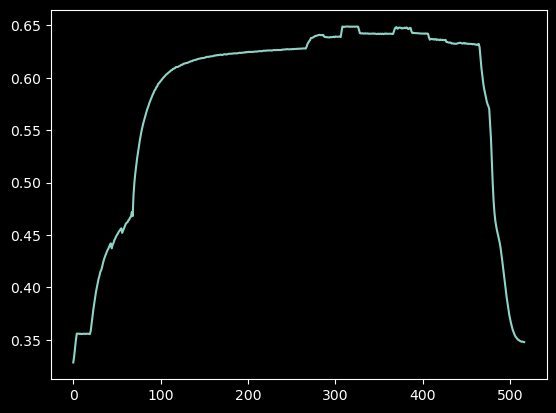

In [104]:
plt.plot(arr1[1:] / arr2[1:])

In [91]:
buf1[3]

129

In [92]:
cs

129

In [88]:
np.frombuffer(buf, np.uint32).sum()%256

120

In [75]:
56007%256

199

In [78]:
199-33

166